<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%203%20%E2%80%94%20Computer%20Vision%20Preprocessing%20with%20OpenCV/Day3_Computer_Vision_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 3 — Computer Vision Preprocessing with OpenCV



## Learning Objectives
- Preprocess images with OpenCV: resize, color-convert, normalize.
- Build an augmentation pipeline for image training data.
- Match preprocessing to a pre-trained model's expectations.



---




## Section 1:  Why Images Need Preprocessing

Just like text, raw images cannot be fed directly into a model. Photos come in different sizes, different color formats, and different pixel value ranges. If we don't fix this, training will either break (mismatched shapes) or quietly get worse (inconsistent inputs confuse the model).

Preprocessing makes every image **consistent**: same size, same channel format (color order), and same pixel value range. Once every image looks "the same shape" to the model, it can actually learn patterns instead of fighting noisy, inconsistent input.


-----

## Section 2 : OpenCV Fundamentals

OpenCV (`cv2`) is the standard library for image processing in Python. Every computer vision pipeline uses some combination of these four operations:

| Operation | Purpose |
|---|---|
| Read / resize | Load an image and standardize its dimensions |
| Color conversion | Switch between BGR, RGB, and grayscale as needed |
| Normalization | Scale pixel values from 0–255 down to 0–1 for stable training |
| Edge detection | Highlight boundaries (e.g. Canny) for classical feature work |

A typical preprocessing sequence looks like this:

```python
import cv2
img = cv2.imread("image.jpg")
img = cv2.resize(img, (128, 128))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = img / 255.0  # normalize pixel values to 0-1
```

**The BGR vs. RGB pitfall:** OpenCV reads images in **BGR** order, not RGB. If you forget to convert, colors get silently swapped (reds look blue, blues look red). This bug doesn't crash your code — it just quietly corrupts your data. Always convert to RGB before feeding a model that expects RGB input.


----

## Section 3:  Building an Augmentation Pipeline

Data augmentation was introduced in Week 7. Today we apply it as a proper **preprocessing pipeline**: random flips, rotations, zooms, brightness shifts, and crops generate new, slightly-varied versions of each training image on the fly.

This does two things:
- It expands a small dataset, since each original image can produce many variations.
- It forces the model to generalize instead of memorizing exact pixels — this is the main defense against overfitting in the Image Classifier project.

Keras' `ImageDataGenerator` is a simple way to build this pipeline:

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    rescale=1./255)
```



---





## Section 4 : Connecting to Transfer Learning

When using transfer learning (Week 7) with models like ResNet or MobileNet, preprocessing must match **exactly** how the base model was originally trained — same input size, same normalization scheme. Most frameworks ship a matching `preprocess_input` function for this exact reason.

Mismatched preprocessing (e.g. normalizing 0–1 when the model expects -1 to 1) is one of the most common causes of disappointing transfer-learning results, and it's easy to miss because the code still runs without errors.


---
# Hands-On Lab: Image Preprocessing




## Setup

 This cell first  installs/imports what we need and downloads one sample image to work with.

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Download a sample image to work with (public TensorFlow example image)
IMAGE_URL = "https://raw.githubusercontent.com/thimarArda/BinX_AI_-_ML_Training/main/Week8_NLP_and_ComputerVision/Day%203%20%E2%80%94%20Computer%20Vision%20Preprocessing%20with%20OpenCV/Usagi.jpg"
IMAGE_PATH = "sample_image.jpg"
urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

print("Sample image downloaded:", IMAGE_PATH)

Sample image downloaded: sample_image.jpg


## Step 1: OpenCV Preprocessing Function

We build one function that does everything a CV pipeline needs:
1. Read the image from disk.
2. Resize it to a fixed size.
3. Convert it from BGR (OpenCV's default) to RGB.
4. Normalize pixel values from 0–255 to 0–1.




In [ ]:
def preprocess_image(image_path, target_size=(128, 128)):
    """Read an image and prepare it for a model: resize, RGB, normalize."""
    img = cv2.imread(image_path)                        # OpenCV reads in BGR
    if img is None:
        raise ValueError(f"Failed to load image from {image_path}. Check if the path is correct and the file is a valid image.")
    img = cv2.resize(img, target_size)                   # standardize size
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)            # fix the BGR pitfall
    img = img / 255.0                                     # normalize to 0-1
    return img

processed = preprocess_image(IMAGE_PATH)

print("Shape:", processed.shape)
print("Pixel value range:", processed.min(), "to", processed.max())

Shape: (128, 128, 3)
Pixel value range: 0.00392156862745098 to 1.0


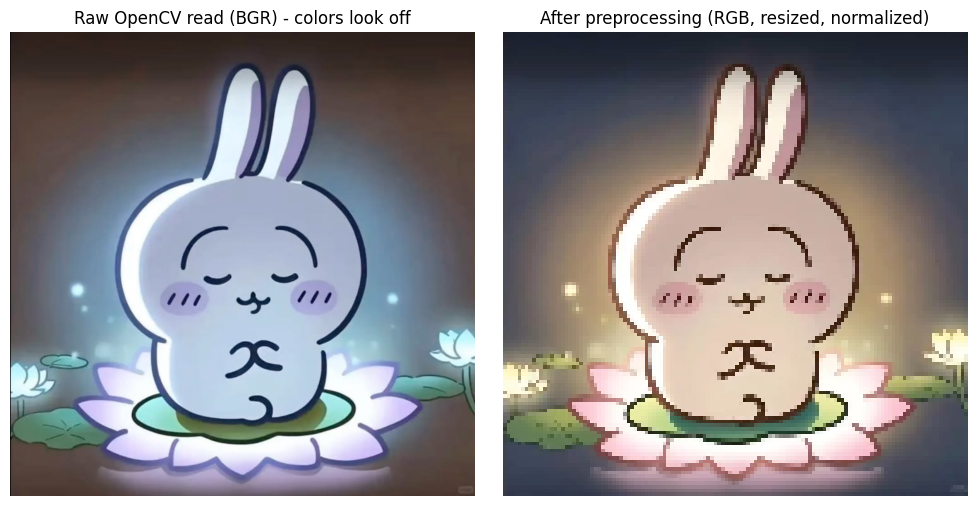

In [ ]:
# Visualize the original (BGR, untouched) vs. the preprocessed (RGB, normalized) image
original_bgr = cv2.imread(IMAGE_PATH)
original_rgb_wrong = original_bgr  # shown as-is, on purpose, to see the BGR pitfall

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_rgb_wrong)
axes[0].set_title("Raw OpenCV read (BGR) - colors look off")
axes[0].axis("off")

axes[1].imshow(processed)
axes[1].set_title("After preprocessing (RGB, resized, normalized)")
axes[1].axis("off")

plt.tight_layout()
plt.show()


Notice the color difference in the left image — that's the BGR vs. RGB pitfall in action. The right image, after our `preprocess_image` function, has correct colors, a fixed size, and pixel values between 0 and 1.

> The pixelation is the resolution loss from resizing. We shrunk every image to a small, fixed size (128×128) so that all images going into the model have the same shape.

## Step 2: Augmentation Pipeline

Now we build an augmentation pipeline with `ImageDataGenerator` and visualize several augmented versions of the same image, to see the kind of variety it creates.


> this cell defines the augmentation rules, prepares one image in the shape the tool expects, and creates a generator that will spit out endless randomly-varied versions of that image on demand — which is exactly what the next cell uses to show you 5 different augmented copies.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    rescale=1./255)

# ImageDataGenerator expects a batch of images: shape (batch, height, width, channels)
img_for_aug = cv2.cvtColor(cv2.imread(IMAGE_PATH), cv2.COLOR_BGR2RGB)
img_for_aug = cv2.resize(img_for_aug, (128, 128))
batch = np.expand_dims(img_for_aug, axis=0)

aug_iterator = datagen.flow(batch, batch_size=1)


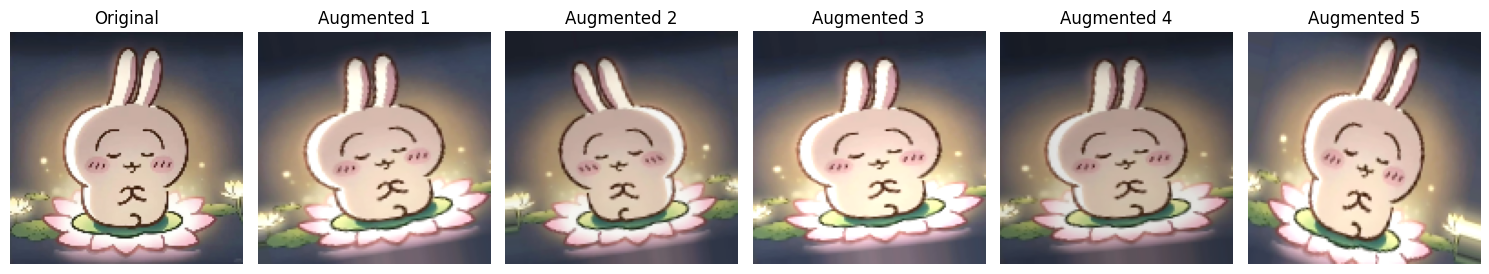

In [ ]:
# Visualize the original plus 5 augmented versions
num_augmented = 5
fig, axes = plt.subplots(1, num_augmented + 1, figsize=(15, 3))

axes[0].imshow(img_for_aug)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(num_augmented):
    augmented_batch = next(aug_iterator)
    augmented_img = augmented_batch[0]
    axes[i + 1].imshow(augmented_img)
    axes[i + 1].set_title(f"Augmented {i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()


Each augmented image is a slightly different version of the same photo: rotated, zoomed, flipped, or with different brightness. During training, the model sees a new random variation almost every time, which helps it generalize instead of memorizing exact images.


## Step 3: Matching Preprocessing to a Pre-Trained Model




**What is MobileNetV2?**

MobileNetV2 is a pre-trained image classification model — a neural network that Google researchers already trained to recognize 1,000 different everyday object categories (dogs, cars, coffee mugs, keyboards, etc.). It's called "Mobile"Net because it's designed to be small and fast enough to run on phones, while still being reasonably accurate.

> `model.predict()` feeds our image through the network and gets back a list of 1,000 numbers — one probability per category, e.g. "2% chance cat, 0.1% chance toaster, 87% chance military uniform," etc.


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from tensorflow.keras.applications import MobileNetV2

# Read and resize to the input size MobileNetV2 expects
img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (224, 224))  # MobileNetV2's expected input size

# Apply the model-specific preprocessing (NOT our manual /255.0 normalization)
img_batch = np.expand_dims(img_resized, axis=0)
img_ready = preprocess_input(img_batch)

print("Shape expected by MobileNetV2:", img_ready.shape)
print("Pixel value range after preprocess_input:", img_ready.min(), "to", img_ready.max())


Shape expected by MobileNetV2: (1, 224, 224, 3)
Pixel value range after preprocess_input: -0.9764706 to 1.0


In [ ]:
# Optional: run the pre-trained model on our preprocessed image to see it work end-to-end
model = MobileNetV2(weights="imagenet")
predictions = model.predict(img_ready)
top_predictions = decode_predictions(predictions, top=3)[0]

print("Top 3 predictions:")
for _, label, confidence in top_predictions:
    print(f"  {label}: {confidence:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Top 3 predictions:
  plate_rack: 8.08%
  wall_clock: 7.86%
  hook: 5.69%


the model used is trained to predict everyday objects so it failed to recognize the cartoon character image I added. But it categorized it under close categories in shape.

tensorflow.keras.applications models (MobileNet, ResNet, EfficientNet, etc.) are all trained on the same ImageNet photo dataset, so they'd all hit the same wall: no cartoon category exists in their labels but I wanted to use that image anyways


## Summary

- We standardized images with OpenCV: resize, convert BGR→RGB, normalize to 0–1.
- We saw the BGR vs. RGB pitfall directly, by comparing a raw OpenCV read to a corrected one.
- We built an augmentation pipeline with `ImageDataGenerator` and visualized several augmented versions of one image.
- We matched preprocessing to a pre-trained model (MobileNetV2) using its own `preprocess_input` function, instead of our manual normalization.
